# Transfer Learning — AC CTRL → Reactor Ciclopentanol
Transferir el agente AC pre-entrenado (CSTR original) al reactor de Ciclopentanol.

**Objetivo:** Demostrar que el agente RL puede transferir conocimiento de ajuste PID
entre reactores CSTR con dinámicas diferentes.

**Baselines de comparación (informe 2015):**
- Ziegler-Nichols: Kp=1081.4, τI=0.020, τD=0.005
- Ajuste manual: CB→v (Kp=100, Ki=1000, Kd=0.01), T→QK (Kp=20, Ki=2000, Kd=0)

**Dos experimentos:**
1. Transfer Learning (cargar pesos del CSTR y fine-tunear)
2. From Scratch (entrenar desde cero para comparar velocidad de convergencia)

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1744, done.
remote: Counting objects: 100% (304/304), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 1744 (delta 182), reused 216 (delta 100), pack-reused 1440 (from 1)
Receiving objects: 100% (1744/1744), 40.99 MiB | 22.50 MiB/s, done.
Resolving deltas: 100% (1046/1046), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.Simulation_Env.Reactor_Cyclopentanol import CyclopentanolReactor
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.Simulation_Env.SimulationEnv import SimulationPIDEnv
from Agente.Actor_Critic.train_AC import ACTrainer
from Agente.Actor_Critic.algorithm_AC import ACAgent
from Agente.memory import SimpleReplayBuffer
from Agente.Actor_Critic.transfer_learning_AC import setup_transfer_learning, freeze_layers
from Aux.PIDComponents_PID import PIDController
from Aux.PIDComponents_time import ResponseTimeDetector
from Aux.PIDComponentes_translate import ApplyAction

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


## 2. Configuración

In [11]:
# ============ FIJOS ============
SEED   = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ============ REACTOR CICLOPENTANOL ============
N_MANIPULABLE_VARS = 2
MANIPULABLE_RANGES = [(0.5, 1.5), (395.0, 420.0)]    # PVs: CB y T
ACTUATOR_LIMITS    = [(50.0, 800.0), (-8500.0, 0.0)]  # Actuadores: v y QK
DT = 0.01  # horas (dinámica más rápida que el CSTR original)

# ============ HIPERPARÁMETROS DEL MEJOR AC (del sweep CSTR) ============
# IMPORTANTE: deben coincidir con el modelo pre-entrenado
HIDDEN_DIMS  = (256, 128, 64)    # del sweep ganador
LR_ACTOR     = 1e-05
LR_CRITIC    = 1e-03
GAMMA        = 0.99
ENTROPY_COEF = 0.01

# ============ CHECKPOINT DEL MODELO PRE-ENTRENADO ============
AC_CHECKPOINT = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/AC/CSTR/agent_ctrl_best.pt'

# ============ REPRODUCIBILIDAD ============
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f'Config lista | Device: {DEVICE} | Seed: {SEED}')

Config lista | Device: cpu | Seed: 42


## 3. Verificar Reactor Ciclopentanol

In [5]:
# Crear reactor y verificar estado estacionario
reactor_test = CyclopentanolReactor(dt=DT, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
reactor_test.verify_steady_state()

# Simular 10 horas en SS para verificar estabilidad
reactor_test.reset()
for _ in range(1000):
    pvs = reactor_test.simulate_step_multi([reactor_test.v_ss, reactor_test.QK_ss], DT)
print(f'\nEstabilidad 10h: CB={pvs[0]:.4f} (SS={reactor_test.CB_ss:.4f}), T={pvs[1]:.2f} (SS={reactor_test.T_ss:.2f})')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [0.5, 1.5] L/h
   Límites QK: [395.0, 420.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.8136774238347021, T=407.6979422715857
   Paso de tiempo: 0.01 h

--- Verificación de Estado Estacionario ---
dCA/dt = -0.000000 (debería ser ~0)
dCB/dt = -0.000000 (debería ser ~0)
dT/dt  = 0.0000 (debería ser ~0)

k1 = k2 = 52.39 h⁻¹ (esperado: ~50.17)
k3 = 7.05 L/(mol·h) (esperado: ~6.69)
v/V = 18.83 h⁻¹ (esperado: 18.83)

Correcto Estado estacionario válido

Estabilidad 10h: CB=-0.0006 (SS=0.8137), T=488.10 (SS=407.70)


## 4. Entrenamiento con Transfer Learning

In [12]:
# ============ CONFIG TRANSFER LEARNING ============

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_AC_TransferLearning'
RUN_NAME      = 'ac_transfer_cyclopentanol'

N_EPISODES             = 5000
EVAL_FREQUENCY         = 100
LOG_FREQUENCY          = 100
SAVE_FREQUENCY         = 1000
EARLY_STOPPING_PATIENCE = 20

trainer_config_transfer = {
    'env_config': {
        'architecture'           : 'simple',
        'env_type'               : 'simulation',
        'action_type'            : 'continuous',
        'n_manipulable_vars'     : N_MANIPULABLE_VARS,
        'manipulable_ranges'     : MANIPULABLE_RANGES,
        'manipulable_setpoints'  : None,
        'dt_usuario'             : DT,
        'max_steps'              : 100,
        'max_time_detector'      : 5.0,      # 5 horas max por step
        'reward_dead_band'       : 0.02,
        'delta_percent_ctrl'     : 0.2,
        'reward_weights'         : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.0},
        'pid_limits'             : [(0.01, 5000.0), (0.0, 5000.0), (0.0, 10.0)],
        'agent_controller_config': {'agent_type': 'continuous'},
        'env_type_config'        : {
            'dt': DT,
            'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
        },
        'stability_config': {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.3,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.2,
        },
    },
    'agent_ctrl_config': {
        'algorithm'    : 'ac',
        'state_dim'    : N_MANIPULABLE_VARS * 5,   # 10
        'action_dim'   : N_MANIPULABLE_VARS * 3,   # 6
        'n_vars'       : N_MANIPULABLE_VARS,
        'action_type'  : 'continuous',
        'hidden_dims'  : HIDDEN_DIMS,               # (64, 32) ← DEBE coincidir
        'lr_actor'     : LR_ACTOR / 3,              # 3x menor para fine-tuning
        'lr_critic'    : LR_CRITIC / 3,             # 3x menor para fine-tuning
        'gamma'        : GAMMA,
        'entropy_coef' : ENTROPY_COEF * 2,          # Más exploración al inicio
        'batch_size'   : 64,
        'buffer_size'  : 50000,
        'warmup_steps' : 200,                        # Menos warmup (ya sabe algo)
        'device'       : DEVICE,
        'seed'         : SEED,
    },
    'n_episodes'                  : N_EPISODES,
    'eval_frequency'              : EVAL_FREQUENCY,
    'log_frequency'               : LOG_FREQUENCY,
    'save_frequency'              : SAVE_FREQUENCY,
    'checkpoint_dir'              : f'checkpoints/{RUN_NAME}',
    'early_stopping_patience'     : EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb': True,
}

In [13]:
# ============ CREAR REACTOR + ENVIRONMENT ============
reactor_transfer = CyclopentanolReactor(
    dt=DT,
    control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1])
)



# ============ CREAR TRAINER (crea el env internamente) ============
trainer_transfer = ACTrainer(trainer_config_transfer)
trainer_transfer.env.proceso.connect_external_process(reactor_transfer)

# ============ OVERRIDE: los PID outputs van a los actuadores, no a los PVs ============
trainer_transfer.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]  # v
trainer_transfer.env.pid_controllers[1].output_limits = ACTUATOR_LIMITS[1]  # QK


# ============ TRANSFER LEARNING: cargar pesos + congelar capas ============
agent_transfer = setup_transfer_learning(
    agent_class=ACAgent,
    checkpoint_path=AC_CHECKPOINT,
    lr_actor=LR_ACTOR / 3,
    lr_critic=LR_CRITIC / 3,
    freeze_strategy='early',     # Congelar primera capa
    n_freeze=2,
    entropy_coef=ENTROPY_COEF * 2,
    state_dim=10,
    action_dim=6,
    n_vars=2,
    hidden_dims=HIDDEN_DIMS,
    buffer_size=50000,
    batch_size=64,
    warmup_steps=200,
    device=DEVICE
)

# Reemplazar el agente del trainer con el pre-entrenado
trainer_transfer.agent_ctrl = agent_transfer
print('\n Agente con transfer learning conectado al trainer')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
 CONFIGURANDO TRANSFER LEARNING
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
Dimensiones compatibles: state_dim=10, hidden[0]=256
   Pesos pre-entrenados cargados desde: /content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/AC/CSTR/agent_ctrl_best.pt
   Training steps previos: 224252
   Episodios previos: 0
Congeladas 2 capas tempranas (8 parámetros)
   Actor:  9036/44748 parámetros entrenables
   Critic: 8321/44033 parámetros entrenables
Replay buffer limpiado
Contadores reseteados
Agente listo para fine-tuning
   LR Actor:  3.3333333333333337e-

In [ ]:
# ============ INIT WANDB ============
wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = RUN_NAME,
    tags    = ['ac', 'transfer_learning', 'cyclopentanol'],
    config  = trainer_config_transfer,
)

# ============ ENTRENAR ============
trainer_transfer.train()

# ============ MÉTRICAS FINALES ============
wandb.log({
    'final_eval_reward'       : trainer_transfer.best_reward,
    'total_episodes'          : len(trainer_transfer.episode_rewards),
    'final_reward_mean10'     : np.mean(trainer_transfer.episode_rewards[-10:]),
    'final_energy_mean10'     : np.mean(trainer_transfer.episode_energies[-10:]),
    'final_overshoot_mean10'  : np.mean(trainer_transfer.episode_max_overshoots[-10:]),
}, step=len(trainer_transfer.episode_rewards))

wandb.finish()
print(f'Transfer Learning completado: {RUN_NAME}')

actor_loss,██▇▁▃▅▆▆▆▆▇▇▇▇▇█▇▇█▇▆▇▇▇▇▇▇▇▇▇█▇██▇▇▇▇▇▇
critic_loss,▆▄▃▂▂▄▂▃▂▄▃▁▁▁▁▂▂▂▃▂▂▃▂▁▄▂▂▃▃▂▂▃▄▃▃▅▃▅█▄
energy,▅▁▇▁██████▁██████▁▁█▂█▁▁█▁█▁▁█▁█▁███▁██▁
eval_reward,█▁
kd_var0,▃▁▁█▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▃▃▁▂▇▂▃▁▁▁▁▁▃▃▁▁▁▃
kd_var1,▄▁▄▁▂▄▂▁▁▅▁▃▁▃▁▄▃▃▃▁▁▅▁▁▃▁▄▁▂▁▁▂▁▁▁▁▁▄█▁
ki_var0,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇███
ki_var1,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
kp_var0,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▇▇▇▇██████
kp_var1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...



Episodio 0/5000
  Reward: -0.07 | Length: 101
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Advantage mean: 0.0000

Episodio 100/5000
  Reward: -0.02 | Length: 101
  Actor Loss: -108334.4504 | Critic Loss: 47218598312.8713
  Advantage mean: -2055.2437


wandb: Adding directory to artifact (checkpoints/ac_transfer_cyclopentanol)... Done. 0.0s


Evaluación: Reward promedio = -0.17
AC Agent guardado en: checkpoints/ac_transfer_cyclopentanol/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/5000
  Reward: -0.13 | Length: 101
  Actor Loss: -88322.6975 | Critic Loss: 242949148800.0000
  Advantage mean: -11601.2292
Evaluación: Reward promedio = -0.25
  Sin mejora: 1/20

Episodio 300/5000
  Reward: -0.11 | Length: 101
  Actor Loss: -15231.3755 | Critic Loss: 52488808697.0297
  Advantage mean: 4098.1825


wandb: Adding directory to artifact (checkpoints/ac_transfer_cyclopentanol)... Done. 0.0s


Evaluación: Reward promedio = -0.16
  Sin mejora: 2/20
AC Agent guardado en: checkpoints/ac_transfer_cyclopentanol/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 400/5000
  Reward: -0.38 | Length: 101
  Actor Loss: 19718.5570 | Critic Loss: 13085101740.4356
  Advantage mean: -229.0577
Evaluación: Reward promedio = -0.33
  Sin mejora: 3/20

Episodio 500/5000
  Reward: -0.18 | Length: 101
  Actor Loss: -65510.4704 | Critic Loss: 36761194562.6139
  Advantage mean: -294.6493
Evaluación: Reward promedio = -0.25
  Sin mejora: 4/20

Episodio 600/5000
  Reward: -0.28 | Length: 101
  Actor Loss: -74036.5622 | Critic Loss: 11215256779.7228
  Advantage mean: 265.3516
Evaluación: Reward promedio = -0.16
  Sin mejora: 5/20

Episodio 700/5000
  Reward: -0.12 | Length: 101
  Actor Loss: -74608.3029 | Critic Loss: 11579412461.3069
  Advantage mean: 1309.1128
Evaluación: Reward promedio = -0.19
  Sin mejora: 6/20

Episodio 800/5000
  Reward: -0.12 | Length: 101
  Actor Loss: 142697.4101 | Criti

In [8]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_TransferLearning/model_ac_transfer_cyclopentanol:latest')
artifact_dir = artifact.download()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb:   1 of 1 files downloaded.  


In [13]:
# ============ CARGAR DONDE QUEDÓ ============
RESUME_CHECKPOINT = '/content/artifacts/model_ac_transfer_cyclopentanol:v2/agent_ctrl_best.pt'

# ============ CREAR TODO DE NUEVO ============
reactor_transfer = CyclopentanolReactor(
    dt=DT,
    control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1])
)

checkpoint = torch.load(RESUME_CHECKPOINT, map_location=DEVICE)
trainer_transfer.agent_ctrl.actor.load_state_dict(checkpoint['actor_state_dict'])
trainer_transfer.agent_ctrl.critic.load_state_dict(checkpoint['critic_state_dict'])
trainer_transfer.agent_ctrl.training_step = checkpoint.get('training_step', 0)
print('Pesos cargados (sin optimizadores)')

# ============ ENTRENAR ============
wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    name=RUN_NAME + '_resumed',
    tags=['ac', 'transfer_learning', 'cyclopentanol', 'resumed'],
    config=trainer_config_transfer,
)

trainer_transfer.train()
wandb.finish()

wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.8136774238347021, T=407.6979422715857
   Paso de tiempo: 0.01 h
Pesos cargados (sin optimizadores)



Episodio 0/5000
  Reward: -0.33 | Length: 101
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Advantage mean: 0.0000

Episodio 100/5000
  Reward: -0.12 | Length: 101
  Actor Loss: -320.5187 | Critic Loss: 3288018748.9814
  Advantage mean: -1070.5668


wandb: Adding directory to artifact (checkpoints/ac_transfer_cyclopentanol)... Done. 0.0s


Evaluación: Reward promedio = -0.13
AC Agent guardado en: checkpoints/ac_transfer_cyclopentanol/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/5000
  Reward: -0.04 | Length: 101
  Actor Loss: -623.0099 | Critic Loss: 2690304927.1350
  Advantage mean: -951.1662
Evaluación: Reward promedio = -0.14
  Sin mejora: 1/20

Episodio 300/5000
  Reward: -0.10 | Length: 101
  Actor Loss: -1869.7849 | Critic Loss: 1862043470.1244
  Advantage mean: 640.5702


...

wandb: Adding directory to artifact (checkpoints/ac_transfer_cyclopentanol)... Done. 0.0s


Evaluación: Reward promedio = -0.19
  Sin mejora: 3/20
AC Agent guardado en: checkpoints/ac_transfer_cyclopentanol/agent_ctrl_ep3000.pt
Checkpoint guardado: ep3000

Episodio 3100/5000
  Reward: -0.04 | Length: 101
  Actor Loss: -80.8324 | Critic Loss: 78042393.3320
  Advantage mean: -49.8349
Evaluación: Reward promedio = -0.18
  Sin mejora: 4/20

Episodio 3200/5000
  Reward: -0.01 | Length: 101
  Actor Loss: 89.7023 | Critic Loss: 155211281.2180
  Advantage mean: -246.9318
Evaluación: Reward promedio = -0.15
  Sin mejora: 5/20

Episodio 3300/5000
  Reward: -0.03 | Length: 101
  Actor Loss: -10.8866 | Critic Loss: 98474472.0843
  Advantage mean: -242.3927
Evaluación: Reward promedio = -0.13
  Sin mejora: 6/20

Episodio 3400/5000
  Reward: -0.09 | Length: 101
  Actor Loss: -57.2642 | Critic Loss: 67483362.7140
  Advantage mean: 167.7425
Evaluación: Reward promedio = -0.11
  Sin mejora: 7/20

Episodio 3500/5000
  Reward: -0.01 | Length: 101
  Actor Loss: -296.8246 | Critic Loss: 171128799

wandb: Adding directory to artifact (checkpoints/ac_transfer_cyclopentanol)... Done. 0.0s



Episodio 4000/5000
  Reward: -0.30 | Length: 101
  Actor Loss: -126.5041 | Critic Loss: 56096027.1122
  Advantage mean: -26.3413
Evaluación: Reward promedio = -0.08
  Sin mejora: 13/20
AC Agent guardado en: checkpoints/ac_transfer_cyclopentanol/agent_ctrl_ep4000.pt
Checkpoint guardado: ep4000

Episodio 4100/5000
  Reward: -0.19 | Length: 101
  Actor Loss: 357.3287 | Critic Loss: 402271848.8487
  Advantage mean: -484.5662
Evaluación: Reward promedio = -0.13
  Sin mejora: 14/20

Episodio 4200/5000
  Reward: -0.27 | Length: 101
  Actor Loss: 44.9733 | Critic Loss: 170238942.2931
  Advantage mean: 433.6067
Evaluación: Reward promedio = -0.11
  Sin mejora: 15/20

Episodio 4300/5000
  Reward: -0.30 | Length: 101
  Actor Loss: -93.8418 | Critic Loss: 87753633.0397
  Advantage mean: 162.6466
Evaluación: Reward promedio = -0.11
  Sin mejora: 16/20

Episodio 4400/5000
  Reward: -0.24 | Length: 101
  Actor Loss: 101.1361 | Critic Loss: 595255439.3895
  Advantage mean: 129.7654
Evaluación: Reward

actor_loss,▂▆▄▄▄█▁▄▄▅▅▅▅▃▄▅▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅
critic_loss,▅▆▃▅█▂▂▃▂▃▂▃▂▁▁▁▃▁▁▁▁▁▁▁▁▂▁▁▁▁▂▂▁▁▁▁▁▁▁▁
energy,▁█▁▁▁▁████▁█▁▁▁███▁▁▁▁▁█▁█▁▇█▁▁▁▁█▁█▁▁█▁
eval_reward,▆▆▇▂▅▂▄▁█▅▆▆▇▅▆▇▃▅▄▃██▆▇▅▄▄▅▇▅▆▅▆▁▆▇▇▃▆▅
kd_var0,▂▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▁▁█▂▃▁▁▁▂▄▂▁▂▁▂▁▁▁▁▅▂▃▂▁
kd_var1,▁▁▁▁▂▁▁▂▂█▅▁▁▁▃▁▁▁▃▁▁▁▁▁▅▁▂▁▃▁▁▂▁▁▁▁▂▁▁▁
ki_var0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ki_var1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kp_var0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kp_var1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


## 5. Entrenamiento From Scratch (Baseline)

In [7]:
# ============ CONFIG FROM SCRATCH ============
RUN_NAME_SCRATCH = 'ac_scratch_cyclopentanol'

trainer_config_scratch = trainer_config_transfer.copy()
trainer_config_scratch['agent_ctrl_config'] = {
    'algorithm'    : 'ac',
    'state_dim'    : 10,
    'action_dim'   : 6,
    'n_vars'       : 2,
    'action_type'  : 'continuous',
    'hidden_dims'  : HIDDEN_DIMS,
    'lr_actor'     : LR_ACTOR,       # Original, sin reducir
    'lr_critic'    : LR_CRITIC,
    'gamma'        : GAMMA,
    'entropy_coef' : ENTROPY_COEF,
    'batch_size'   : 64,
    'buffer_size'  : 50000,
    'warmup_steps' : 500,            # Warmup normal
    'device'       : DEVICE,
    'seed'         : SEED,
}
trainer_config_scratch['n_episodes'] = 15000            # Más episodios
trainer_config_scratch['checkpoint_dir'] = f'checkpoints/{RUN_NAME_SCRATCH}'

# ============ CREAR Y ENTRENAR ============
reactor_scratch = CyclopentanolReactor(
    dt=DT,
    control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1])
)
trainer_scratch = ACTrainer(trainer_config_scratch)
trainer_scratch.env.proceso.connect_external_process(reactor_scratch)
trainer_scratch.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]
trainer_scratch.env.pid_controllers[1].output_limits = ACTUATOR_LIMITS[1]

wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    name=RUN_NAME_SCRATCH,
    tags=['ac', 'from_scratch', 'cyclopentanol'],
    config=trainer_config_scratch,
)

trainer_scratch.train()

wandb.log({
    'final_eval_reward': trainer_scratch.best_reward,
    'total_episodes': len(trainer_scratch.episode_rewards),
})
wandb.finish()
print(f'From Scratch completado: {RUN_NAME_SCRATCH}')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.8136774238347021, T=407.6979422715857
   Paso de tiempo: 0.01 h
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cuda


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


...

Evaluación: Reward promedio = -0.09
  Sin mejora: 10/20
AC Agent guardado en: checkpoints/ac_scratch_cyclopentanol/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 2600/15000
  Reward: -0.23 | Length: 101
  Actor Loss: -0.0243 | Critic Loss: 0.2840
  Advantage mean: 0.0167
Evaluación: Reward promedio = -0.17
  Sin mejora: 11/20

Episodio 2700/15000
  Reward: -0.17 | Length: 101
  Actor Loss: -0.0256 | Critic Loss: 0.2419
  Advantage mean: 0.0246
Evaluación: Reward promedio = -0.11
  Sin mejora: 12/20

Episodio 2800/15000
  Reward: -0.14 | Length: 101
  Actor Loss: -0.0173 | Critic Loss: 0.1118
  Advantage mean: 0.0120
Evaluación: Reward promedio = -0.19
  Sin mejora: 13/20

Episodio 2900/15000
  Reward: -0.15 | Length: 101
  Actor Loss: -0.0324 | Critic Loss: 0.3286
  Advantage mean: 0.0311
Evaluación: Reward promedio = -0.17
  Sin mejora: 14/20

Episodio 3000/15000
  Reward: -0.18 | Length: 101
  Actor Loss: -0.0229 | Critic Loss: 0.3700
  Advantage mean: 0.0260


wandb: Adding directory to artifact (checkpoints/ac_scratch_cyclopentanol)... Done. 0.0s


Evaluación: Reward promedio = -0.16
  Sin mejora: 15/20
AC Agent guardado en: checkpoints/ac_scratch_cyclopentanol/agent_ctrl_ep3000.pt
Checkpoint guardado: ep3000

Episodio 3100/15000
  Reward: -0.25 | Length: 101
  Actor Loss: -0.0205 | Critic Loss: 0.2816
  Advantage mean: 0.0278
Evaluación: Reward promedio = -0.10
  Sin mejora: 16/20

Episodio 3200/15000
  Reward: -0.07 | Length: 101
  Actor Loss: -0.0229 | Critic Loss: 0.2177
  Advantage mean: 0.0169
Evaluación: Reward promedio = -0.12
  Sin mejora: 17/20

Episodio 3300/15000
  Reward: -0.19 | Length: 101
  Actor Loss: -0.0269 | Critic Loss: 0.2905
  Advantage mean: 0.0224
Evaluación: Reward promedio = -0.16
  Sin mejora: 18/20

Episodio 3400/15000
  Reward: -0.18 | Length: 101
  Actor Loss: -0.0181 | Critic Loss: 0.2213
  Advantage mean: 0.0197
Evaluación: Reward promedio = -0.14
  Sin mejora: 19/20

Episodio 3500/15000
  Reward: -0.07 | Length: 101
  Actor Loss: -0.0161 | Critic Loss: 0.2032
  Advantage mean: 0.0201
Evaluación: 

actor_loss,█▇▂▁▂▃▇▂▆▅▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
critic_loss,▇▆▆█▅▂▃▄▁▄▁▃▂▁▂▂▂▂▂▅▄▃▂▁▂▁▂▂▁▁▁▂▂▃▂▂▃▂▂▁
energy,▃▇█▁▁▂▂▁▂▁▁▁▂▁▁▁▁▁▁▄▁▁▁▄▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁
eval_reward,▁▆▅▂▁▆▃▆▅▆▄▅▃▆▇▆▄▃▇▇▄▅▅▃█▄▇▃▄▄█▇▅▅▆
final_eval_reward,▁
kd_var0,█▃▂▁▂▂▁▁▁▂▁▁▁▁▂▁▁▁▁▁▁▁▂▁▁▁▁▁▂▂▁▂▁▁▁▂▂▁▁▁
kd_var1,▇█▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▂▁▂▁▁▂▁▁▁▃▁
ki_var0,▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ki_var1,▁███████████████████████████████████████
kp_var0,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+4,...


From Scratch completado: ac_scratch_cyclopentanol


## 6. Comparación: Transfer vs Scratch vs Baselines

In [4]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

api = wandb.Api()

run_transfer = api.run("ve326684-universidad-ort-uruguay/Tesis_AC_TransferLearning/yeu9qwiz")
run_scratch  = api.run("ve326684-universidad-ort-uruguay/Tesis_AC_TransferLearning/ifvrb4nj")

# Bajar historial
df_transfer = run_transfer.history(samples=10000)
df_scratch  = run_scratch.history(samples=10000)



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


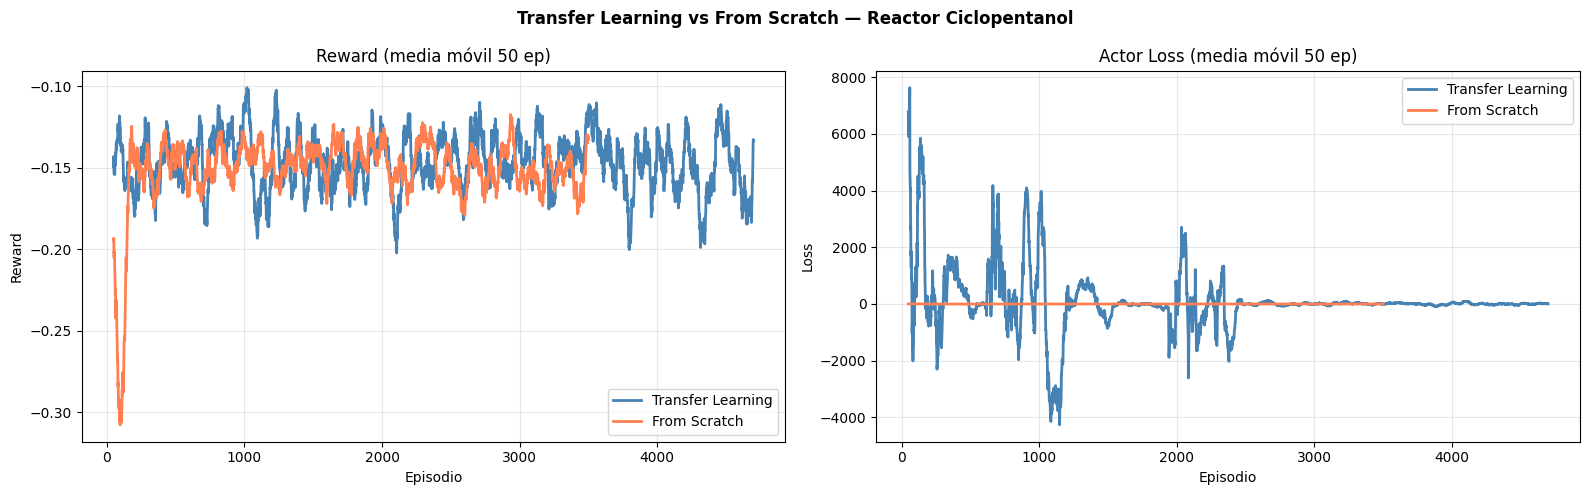

In [6]:
# ============ CURVAS DE CONVERGENCIA ============
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
window = 50

# Reward
axes[0].plot(df_transfer['reward'].rolling(window).mean(), label='Transfer Learning', color='steelblue', linewidth=2)
axes[0].plot(df_scratch['reward'].rolling(window).mean(),  label='From Scratch', color='coral', linewidth=2)
axes[0].set_title('Reward (media móvil 50 ep)')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Reward')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Actor Loss
axes[1].plot(df_transfer['actor_loss'].rolling(window).mean(), label='Transfer Learning', color='steelblue', linewidth=2)
axes[1].plot(df_scratch['actor_loss'].rolling(window).mean(),  label='From Scratch', color='coral', linewidth=2)
axes[1].set_title('Actor Loss (media móvil 50 ep)')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Transfer Learning vs From Scratch — Reactor Ciclopentanol', fontweight='bold')
plt.tight_layout()
plt.savefig('transfer_vs_scratch_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Evaluación del Mejor Agente

In [8]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_TransferLearning/model_ac_transfer_cyclopentanol_resumed:latest')
artifact_dir = artifact.download()

wandb:   5 of 5 files downloaded.  


In [9]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_TransferLearning/model_ac_scratch_cyclopentanol:latest')
artifact_dir = artifact.download()

wandb:   4 of 4 files downloaded.  


In [14]:
# ============ CARGAR MEJOR AGENTE (transfer) ============
BEST_CHECKPOINT = '/content/artifacts/model_ac_transfer_cyclopentanol_resumed:v8/agent_ctrl_best.pt'

agent_eval = ACAgent(
    state_dim=10, action_dim=6, agent_role='ctrl', n_vars=2,
    hidden_dims=HIDDEN_DIMS,
    lr_actor=LR_ACTOR, lr_critic=LR_CRITIC,
    gamma=GAMMA, entropy_coef=ENTROPY_COEF,
    batch_size=64, buffer_size=50000, warmup_steps=500,
    device=DEVICE, seed=SEED
)
agent_eval.load(BEST_CHECKPOINT)
print('Agente cargado')

AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_transfer_cyclopentanol_resumed:v8/agent_ctrl_best.pt
Agente cargado


In [29]:
# ============ EVALUACIÓN MANUAL PASO A PASO ============
reactor_eval = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
reactor_eval.reset()

pid_controllers = [
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[0]),  # v
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[1]),  # QK
]
apply_action = ApplyAction(
    delta_percent_ctrl=0.2,
    pid_limits=[(0.01, 5000.0), (0.0, 50000.0), (0.0, 100.0)],
    manipulable_ranges=MANIPULABLE_RANGES
)

detector = ResponseTimeDetector(proceso=reactor_eval, env_type='simulation', dt=DT, tolerance=0.02)

# Setpoints de prueba
CB_sp, T_sp = 0.95, 410.0
sps = [CB_sp, T_sp]
pvs = reactor_eval.get_initial_pvs()  # [CB_ss, T_ss]

error_integral = [0.0, 0.0]
error_prev     = [sps[i] - pvs[i] for i in range(2)]

traj_CB, traj_T = [pvs[0]], [pvs[1]]
traj_kp0, traj_kp1 = [], []

for step in range(20):
    errors = [sps[i] - pvs[i] for i in range(2)]
    for i in range(2):
        error_integral[i] += errors[i] * DT
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    action = agent_eval.select_action(state, training=False)

    pid_params = apply_action.translate(
        action=action, agent_type='ctrl', action_type='continuous',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    traj_kp0.append(pid_controllers[0].kp)
    traj_kp1.append(pid_controllers[1].kp)

    resultado = detector.estimate(
        pvs_inicial=pvs, sps=sps,
        pid_controllers=pid_controllers,
        max_time=5.0, reset_pid=False
    )

    pvs = resultado['pvs_final']
    traj_CB.append(pvs[0])
    traj_T.append(pvs[1])
    print(f'Step {step+1:2d} | CB={pvs[0]:.4f} | T={pvs[1]:.2f} | '
          f'kp_CB={pid_controllers[0].kp:.4f} | kp_T={pid_controllers[1].kp:.4f}')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Step  1 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  2 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  3 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  4 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  5 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  6 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  7 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  8 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step  9 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step 10 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step 11 | CB=0.8019 | T=410.21 | kp_CB=0.0100 | kp_T=0.0100
Step 12 | CB=0.8019 | T=410.21 | kp_

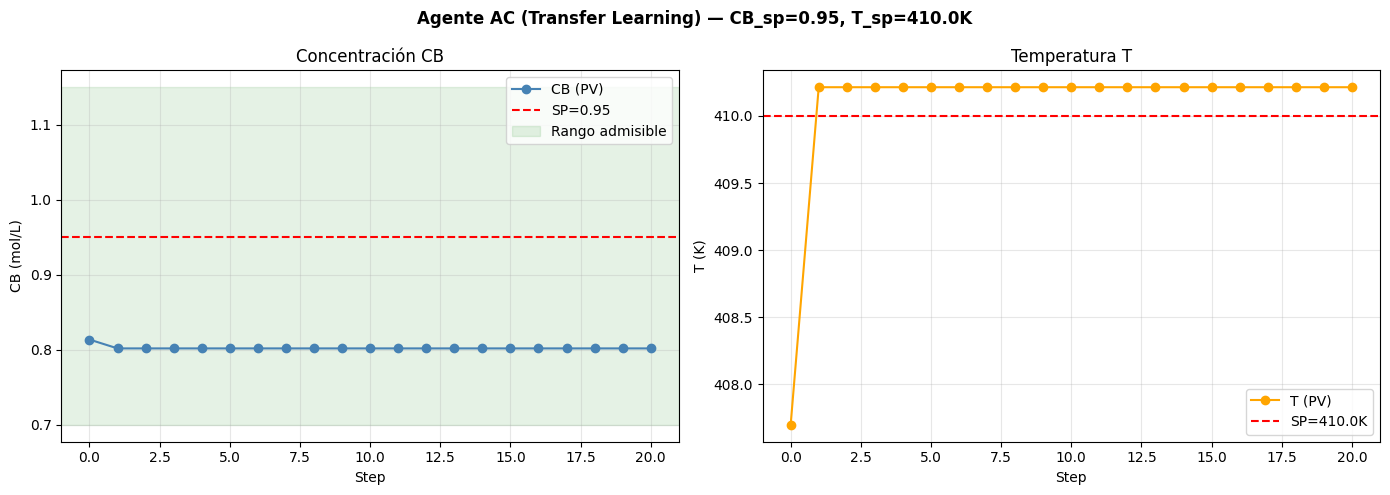

In [30]:
# ============ GRAFICAR ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(traj_CB, marker='o', color='steelblue', label='CB (PV)')
axes[0].axhline(CB_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={CB_sp}')
axes[0].axhspan(0.7, 1.15, alpha=0.1, color='green', label='Rango admisible')
axes[0].set_title('Concentración CB')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(traj_T, marker='o', color='orange', label='T (PV)')
axes[1].axhline(T_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_sp}K')
axes[1].set_title('Temperatura T')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Agente AC (Transfer Learning) — CB_sp={CB_sp}, T_sp={T_sp}K', fontweight='bold')
plt.tight_layout()
plt.savefig('eval_transfer_cyclopentanol.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparación con Baselines del Informe 2015

In [31]:
# ============ BASELINE: PID MANUAL DEL INFORME ============
def run_baseline_pid(reactor, CB_sp, T_sp, Kp_CB, Ki_CB, Kd_CB, Kp_T, Ki_T, Kd_T, n_steps=2000):
    """Simula el reactor con PID fijos (baselines del informe 2015)."""
    reactor.reset()
    integral_CB, integral_T = 0.0, 0.0
    prev_err_CB, prev_err_T = 0.0, 0.0
    dt = reactor.dt
    cb_hist, t_hist = [], []

    for _ in range(n_steps):
        meas = reactor.get_measurements()

        err_CB = CB_sp - meas['CB']
        integral_CB += err_CB * dt
        deriv_CB = (err_CB - prev_err_CB) / dt
        v_out = reactor.v_ss + Kp_CB * err_CB + Ki_CB * integral_CB + Kd_CB * deriv_CB
        v_out = np.clip(v_out, 50, 800)
        prev_err_CB = err_CB

        err_T = T_sp - meas['T']
        integral_T += err_T * dt
        deriv_T = (err_T - prev_err_T) / dt
        QK_out = reactor.QK_ss + Kp_T * err_T + Ki_T * integral_T + Kd_T * deriv_T
        QK_out = np.clip(QK_out, -8500, 0)
        prev_err_T = err_T

        pvs = reactor.simulate_step_multi([v_out, QK_out], dt)
        cb_hist.append(pvs[0])
        t_hist.append(pvs[1])

    return cb_hist, t_hist


# ============ CORRER BASELINES ============
CB_sp, T_sp = 0.95, 410.0

reactor_bl = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))

# Ajuste manual (informe sección 4.3)
cb_manual, t_manual = run_baseline_pid(
    reactor_bl, CB_sp, T_sp,
    Kp_CB=100, Ki_CB=1000, Kd_CB=0.01,
    Kp_T=20, Ki_T=2000, Kd_T=0.0
)

# Ziegler-Nichols CB + manual T
cb_zn, t_zn = run_baseline_pid(
    reactor_bl, CB_sp, T_sp,
    Kp_CB=1081.4, Ki_CB=1081.4/0.020, Kd_CB=0,  # ZN sin Kd (mejor resultado del informe)
    Kp_T=20, Ki_T=2000, Kd_T=0.0
)

print(f'Manual:  CB_final={cb_manual[-1]:.4f} (err={abs(cb_manual[-1]-CB_sp):.5f}), T_final={t_manual[-1]:.2f}')
print(f'Z-N:     CB_final={cb_zn[-1]:.4f} (err={abs(cb_zn[-1]-CB_sp):.5f}), T_final={t_zn[-1]:.2f}')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Manual:  CB_final=0.9496 (err=0.00039), T_final=413.30
Z-N:     CB_final=0.9489 (err=0.00108), T_final=413.25


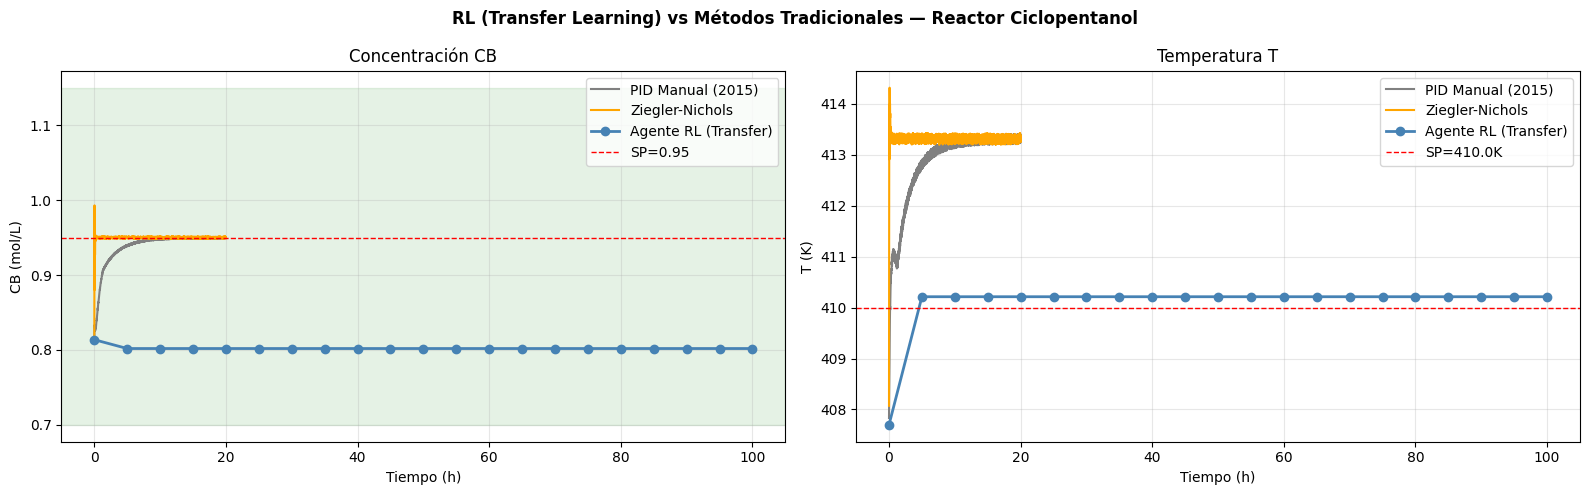

In [32]:
# ============ COMPARAR TODOS ============
time_hours = np.arange(len(cb_manual)) * DT

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# CB
axes[0].plot(time_hours, cb_manual, label='PID Manual (2015)', color='gray', linewidth=1.5)
axes[0].plot(time_hours, cb_zn, label='Ziegler-Nichols', color='orange', linewidth=1.5)
axes[0].plot(np.arange(len(traj_CB)) * (5.0),  # tiempo aprox por step
             traj_CB, label='Agente RL (Transfer)', color='steelblue', linewidth=2, marker='o')
axes[0].axhline(CB_sp, color='red', linestyle='--', linewidth=1, label=f'SP={CB_sp}')
axes[0].axhspan(0.7, 1.15, alpha=0.1, color='green')
axes[0].set_title('Concentración CB')
axes[0].set_xlabel('Tiempo (h)')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# T
axes[1].plot(time_hours, t_manual, label='PID Manual (2015)', color='gray', linewidth=1.5)
axes[1].plot(time_hours, t_zn, label='Ziegler-Nichols', color='orange', linewidth=1.5)
axes[1].plot(np.arange(len(traj_T)) * (5.0),
             traj_T, label='Agente RL (Transfer)', color='steelblue', linewidth=2, marker='o')
axes[1].axhline(T_sp, color='red', linestyle='--', linewidth=1, label=f'SP={T_sp}K')
axes[1].set_title('Temperatura T')
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RL (Transfer Learning) vs Métodos Tradicionales — Reactor Ciclopentanol', fontweight='bold')
plt.tight_layout()
plt.savefig('rl_vs_traditional_cyclopentanol.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Pruebas con otros SP (Grilla)

In [33]:
# ============ GRILLA DE SETPOINTS ============
CB_setpoints = [0.75, 0.85, 0.95, 1.05, 1.10]  # mol/L (rango admisible: 0.7-1.15)
T_setpoints  = [405, 408, 410, 412, 415]        # K

# ============ FUNCIÓN DE EVALUACIÓN ============
eval_config = trainer_config_transfer.copy()
eval_config['n_episodes'] = 1
eval_config['use_wandb'] = False
eval_config['checkpoint_dir'] = 'checkpoints/eval_tmp'

reactor_eval2 = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(reactor_eval2)
trainer_eval.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]
trainer_eval.env.pid_controllers[1].output_limits = ACTUATOR_LIMITS[1]
trainer_eval.agent_ctrl.load(BEST_CHECKPOINT)
print('Agente cargado para evaluación')


def evaluar_sp(trainer, CB_sp, T_sp, max_steps=100):
    state = trainer.env.reset()[0]
    trainer.env.manipulable_setpoints = [CB_sp, T_sp]
    trainer.env._update_errors()
    state = trainer.env._get_observation()

    CB_hist, T_hist = [], []
    done = False
    step = 0

    while not done and step < max_steps:
        action = trainer.agent_ctrl.select_action(state, training=False)
        next_state, reward, terminated, truncated, info = trainer.env.step(action)
        done = terminated or truncated
        CB_hist.append(trainer.env.manipulable_pvs[0])
        T_hist.append(trainer.env.manipulable_pvs[1])
        state = next_state
        step += 1

    return np.array(CB_hist), np.array(T_hist)

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_transfer_cyclopentanol_resumed:v8/agent_ctrl_best.pt
Agente cargado para evaluación


CB_sp=0.75 → CB_final=0.8020 (err=0.0520) | T_final=410.27 (err=0.27K)
CB_sp=0.85 → CB_final=0.8006 (err=0.0494) | T_final=410.32 (err=0.32K)
CB_sp=0.95 → CB_final=0.8006 (err=0.1494) | T_final=410.35 (err=0.35K)
CB_sp=1.05 → CB_final=0.8009 (err=0.2491) | T_final=410.19 (err=0.19K)
CB_sp=1.1 → CB_final=0.8014 (err=0.2986) | T_final=410.21 (err=0.21K)


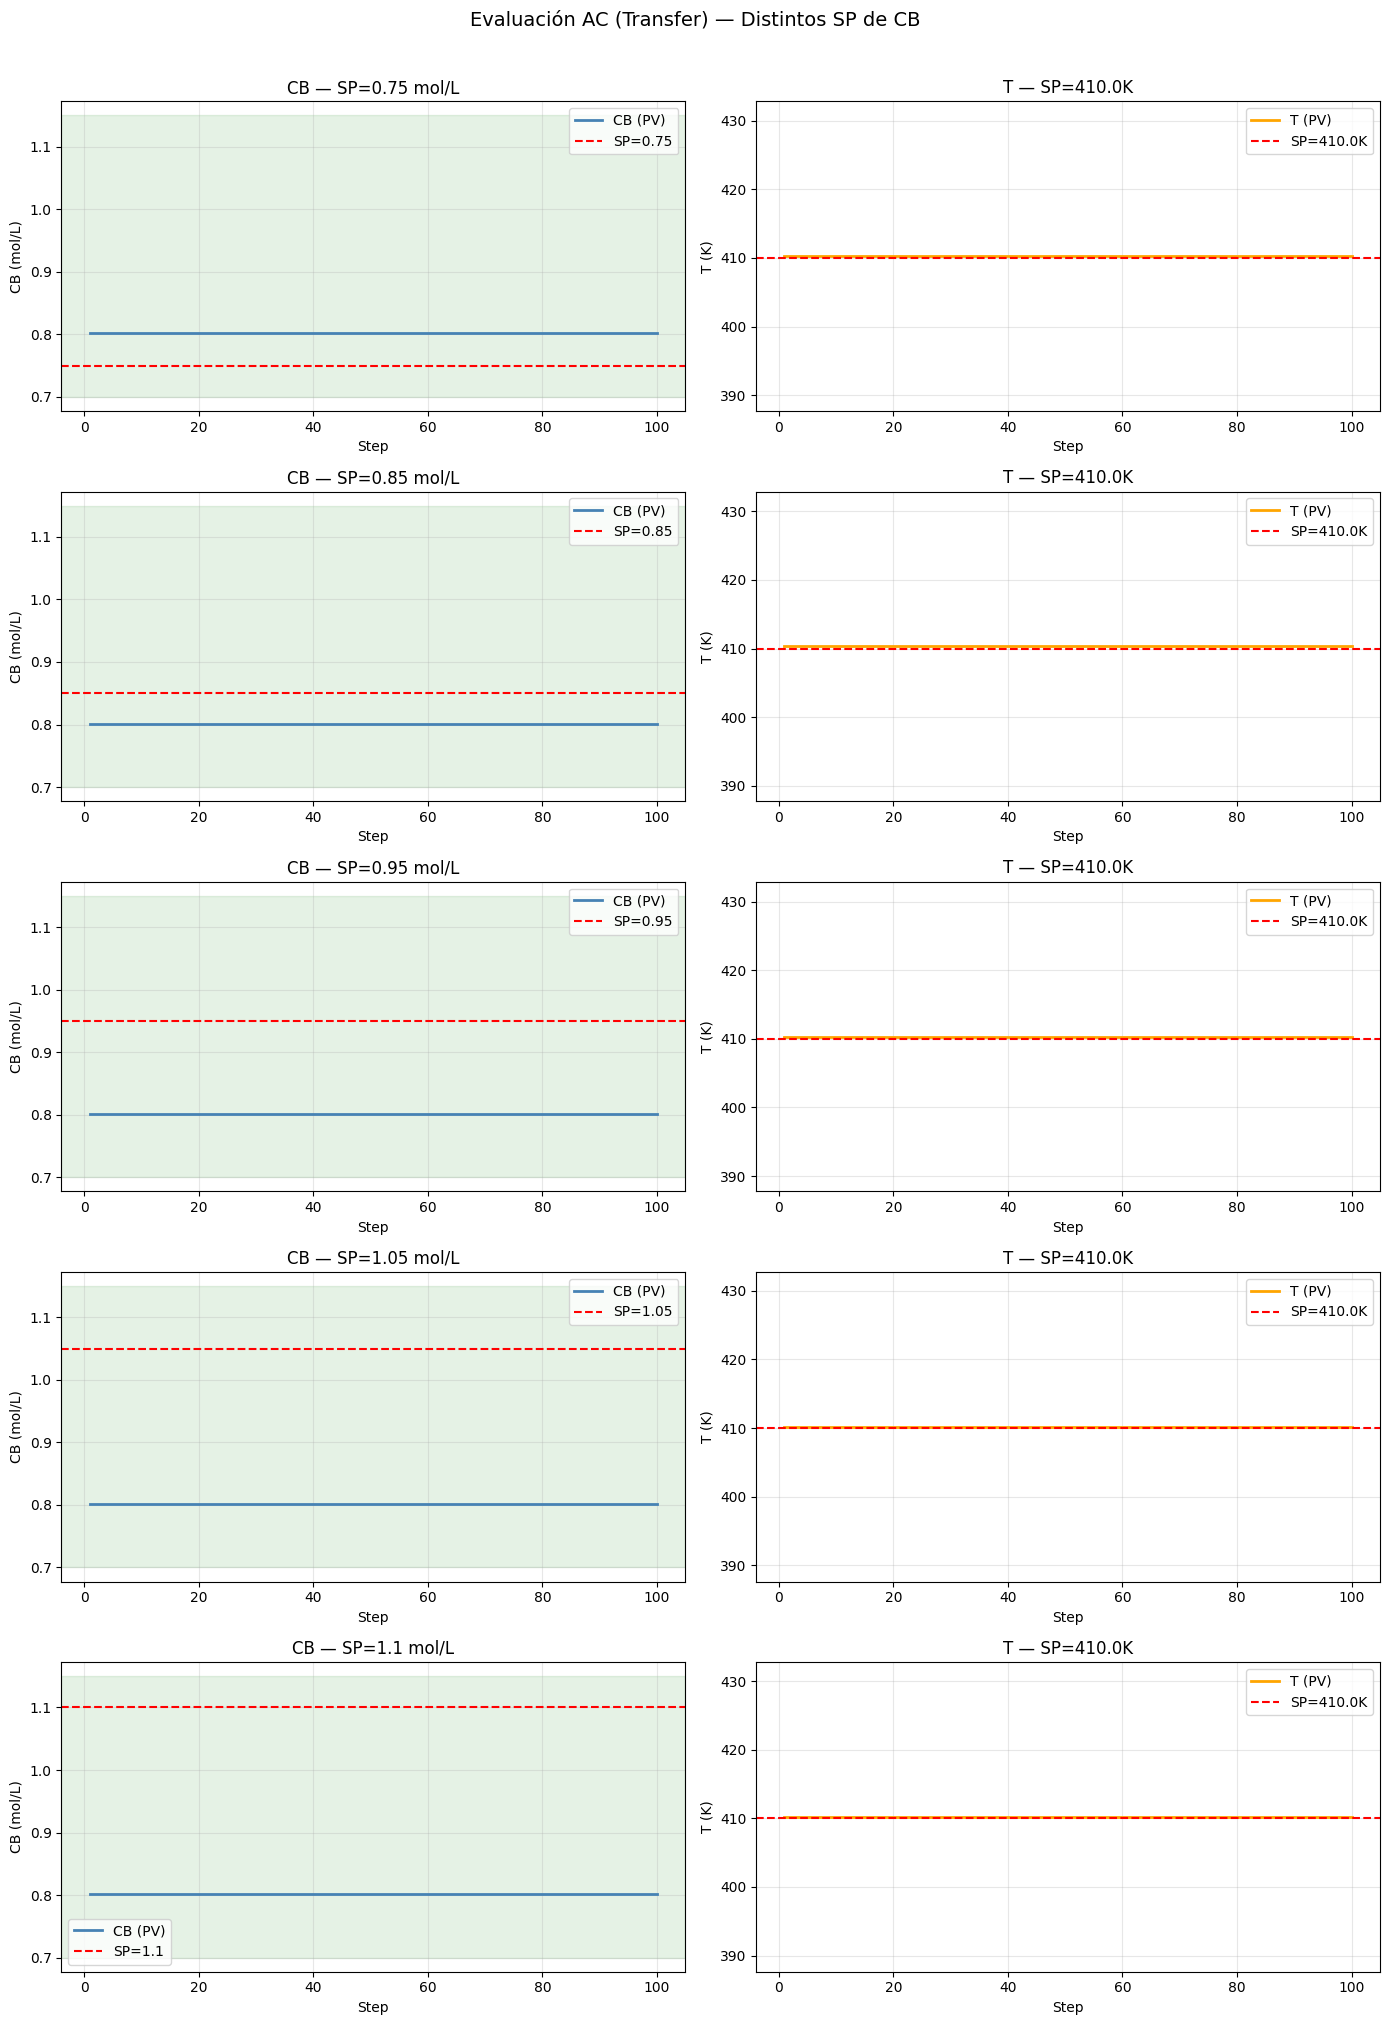

In [34]:
# ============ EVALUAR Y GRAFICAR ============
fig, axes = plt.subplots(len(CB_setpoints), 2, figsize=(14, 4 * len(CB_setpoints)))

T_fijo = 410.0  # Temperatura fija para variar CB

for i, CB_sp in enumerate(CB_setpoints):
    CB_hist, T_hist = evaluar_sp(trainer_eval, CB_sp, T_fijo)
    steps = np.arange(1, len(CB_hist) + 1)

    ax_CB = axes[i, 0]
    ax_CB.plot(steps, CB_hist, color='steelblue', linewidth=2, label='CB (PV)')
    ax_CB.axhline(CB_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={CB_sp}')
    ax_CB.axhspan(0.7, 1.15, alpha=0.1, color='green')
    ax_CB.set_title(f'CB — SP={CB_sp} mol/L')
    ax_CB.set_xlabel('Step')
    ax_CB.set_ylabel('CB (mol/L)')
    ax_CB.legend()
    ax_CB.grid(True, alpha=0.3)

    ax_T = axes[i, 1]
    ax_T.plot(steps, T_hist, color='orange', linewidth=2, label='T (PV)')
    ax_T.axhline(T_fijo, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_fijo}K')
    ax_T.set_title(f'T — SP={T_fijo}K')
    ax_T.set_xlabel('Step')
    ax_T.set_ylabel('T (K)')
    ax_T.legend()
    ax_T.grid(True, alpha=0.3)

    print(f'CB_sp={CB_sp} → CB_final={CB_hist[-1]:.4f} (err={abs(CB_hist[-1]-CB_sp):.4f}) | '
          f'T_final={T_hist[-1]:.2f} (err={abs(T_hist[-1]-T_fijo):.2f}K)')

plt.suptitle('Evaluación AC (Transfer) — Distintos SP de CB', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eval_transfer_CB_setpoints.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Test de Robustez: Perturbación en CA0

Perturbación: CA0 = 5.5 mol/L


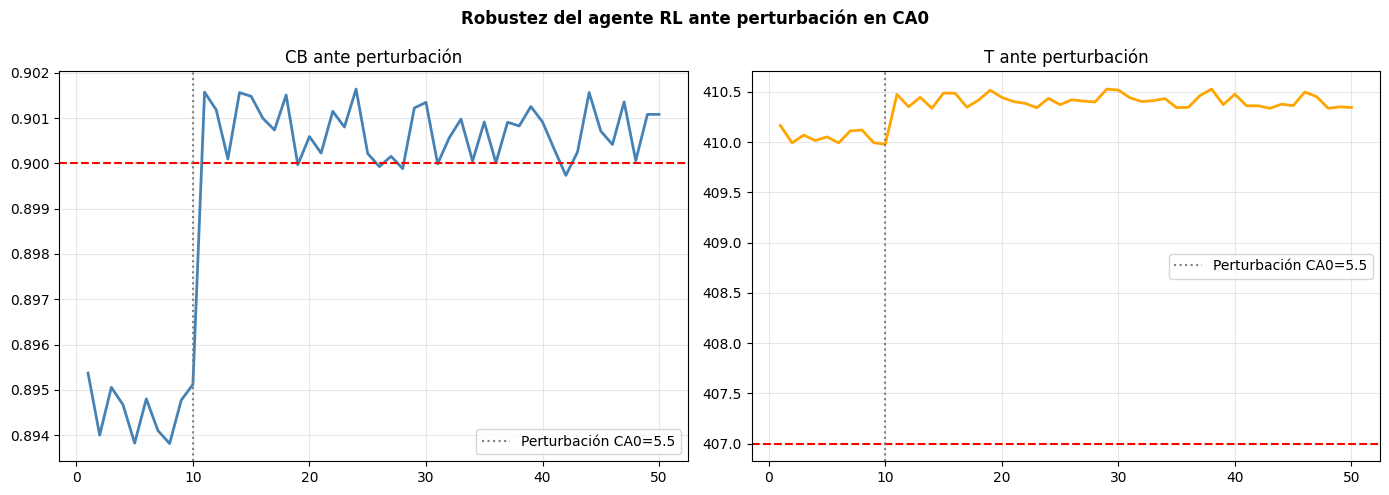

In [35]:
# ============ PERTURBACIÓN: CA0 cambia de 5.1 a 5.5 mol/L ============
# Esto simula un cambio real en la alimentación del reactor.
# Los métodos clásicos NO se adaptan (PID fijo). El agente RL sí.

CB_sp, T_sp = 0.90, 407.0  # Mantener en SS

# --- RL con perturbación ---
state = trainer_eval.env.reset()[0]
trainer_eval.env.manipulable_setpoints = [CB_sp, T_sp]
trainer_eval.env._update_errors()
state = trainer_eval.env._get_observation()

CB_rl, T_rl = [], []
for step in range(50):
    if step == 10:
        reactor_eval2.set_disturbance(CA0=5.5)  # Perturbación en step 10
    action = trainer_eval.agent_ctrl.select_action(state, training=False)
    next_state, _, _, _, _ = trainer_eval.env.step(action)
    CB_rl.append(trainer_eval.env.manipulable_pvs[0])
    T_rl.append(trainer_eval.env.manipulable_pvs[1])
    state = next_state

# --- Graficar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps = np.arange(1, len(CB_rl) + 1)

axes[0].plot(steps, CB_rl, color='steelblue', linewidth=2)
axes[0].axhline(CB_sp, color='red', linestyle='--')
axes[0].axvline(10, color='gray', linestyle=':', label='Perturbación CA0=5.5')
axes[0].set_title('CB ante perturbación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, T_rl, color='orange', linewidth=2)
axes[1].axhline(T_sp, color='red', linestyle='--')
axes[1].axvline(10, color='gray', linestyle=':', label='Perturbación CA0=5.5')
axes[1].set_title('T ante perturbación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Robustez del agente RL ante perturbación en CA0', fontweight='bold')
plt.tight_layout()
plt.savefig('robustez_perturbacion_CA0.png', dpi=150, bbox_inches='tight')
plt.show()